In [ ]:
#Robert Yarel Zapata

import numpy as np
import matplotlib.pyplot as plt
import copy

# --- Definición del Sudoku basico ---
filas = "ABCDEFGHI"
columnas = "123456789"

class SudokuSolver:
    """
    Clase para resolver Sudokus estándar y diagonales.

    Inicializa el tablero, define las unidades (filas, columnas, bloques y diagonales opcionales)
    y los pares de celdas relacionadas, y contiene métodos para aplicar estrategias de resolución
    y búsqueda por retroceso.
    """
    def __init__(self, tablero_texto):
        """
        Inicializa una nueva instancia de SudokuSolver.

        Args:
            tablero_texto (str): Una cadena de 81 caracteres que representa el Sudoku,
                                 donde '.' indica una celda vacía y los dígitos son los valores iniciales.
        """
        self.celdas = self._cross(filas, columnas)

        self.celdas_filas = [self._cross(fila, columnas) for fila in filas]
        self.celdas_cols = [self._cross(filas, col) for col in columnas]
        self.celdas_cuad = [self._cross(fs, cs) for fs in ('ABC', 'DEF', 'GHI') for cs in ('123', '456', '789')]
        self.unidades_estandar = self.celdas_filas + self.celdas_cols + self.celdas_cuad
        self.pares_estandar = {c: set(sum([u for u in self.unidades_estandar if c in u], [])) - {c} for c in self.celdas}

        self.diag1 = [filas[i] + columnas[i] for i in range(9)]
        self.diag2 = [filas[i] + columnas[8 - i] for i in range(9)]

        # Guardamos las celdas de las diagonales para un acceso rápido en plot_display
        self.celdas_diag1_set = set(self.diag1)
        self.celdas_diag2_set = set(self.diag2)

        self.unidades_diagonal = self.unidades_estandar + [self.diag1, self.diag2]
        self.pares_diagonal = {c: set(sum([u for u in self.unidades_diagonal if c in u], [])) - {c} for c in self.celdas}

        self.tablero_inicial_texto = tablero_texto
        self.tablero = self._text_2_dict(tablero_texto)
        if self.tablero:
            self.tablero = self._rellenar_celdas(self.tablero)

    def _cross(self, a, b):
        """
        Genera todas las combinaciones posibles de dos secuencias.

        Por ejemplo, _cross('AB', '12') retornará ['A1', 'A2', 'B1', 'B2'].

        Args:
            a (str): La primera secuencia de caracteres.
            b (str): La segunda secuencia de caracteres.

        Returns:
            list: Una lista de cadenas, donde cada cadena es una combinación de un caracter de 'a' y uno de 'b'.
        """
        return [i + j for i in a for j in b]

    def _text_2_dict(self, tablero_texto):
        """
        Convierte una cadena de texto de Sudoku en un diccionario de celdas.

        Cada clave del diccionario es el identificador de la celda (ej. 'A1', 'B5')
        y su valor es el dígito inicial o un '.' si está vacío.

        Args:
            tablero_texto (str): Una cadena de 81 caracteres que representa el Sudoku.

        Returns:
            dict: Un diccionario donde las claves son identificadores de celdas y los valores son los dígitos iniciales.
                  Retorna None si la longitud del tablero_texto no es 81.
        """
        if len(tablero_texto) != 81:
            print(f"Error: El tablero debe tener exactamente 81 caracteres. (Longitud recibida: {len(tablero_texto)})")
            return None
        return {celda: valor for (celda, valor) in zip(self.celdas, tablero_texto)}

    def _rellenar_celdas(self, tablero):
        """
        Inicializa los valores de las celdas en el diccionario del tablero.

        Las celdas vacías (representadas por '.') se rellenan con todos los candidatos posibles ('123456789').
        Las celdas con un dígito inicial mantienen ese dígito.

        Args:
            tablero (dict): Un diccionario del tablero de Sudoku con los valores iniciales.

        Returns:
            dict: Un nuevo diccionario del tablero con las celdas vacías inicializadas con todos los candidatos.
        """
        return {celda: valor.replace('.', '123456789') for (celda, valor) in tablero.items()}

    def plot_display(self, tablero=None, title="Sudoku Board", pause_time=None, highlight_diagonals=False):
        """
        Visualiza el tablero de Sudoku usando Matplotlib.
        Muestra los números resueltos en negrita y los candidatos más pequeños en las celdas no resueltas.
        Ajusta el grosor de las líneas de la cuadrícula.

        Args:
            tablero (dict): El tablero a mostrar. Si es None, usa self.tablero.
            title (str): Título del gráfico.
            pause_time (float, optional): Tiempo en segundos para que la ventana permanezca abierta.
                                          Si es None, la ventana permanece abierta hasta que se cierra manualmente.
            highlight_diagonals (bool): Si es True, sombrea el fondo de las celdas que forman las diagonales.
        """
        board_to_display = tablero if tablero is not None else self.tablero

        if not board_to_display or (isinstance(board_to_display, bool) and not board_to_display):
            print("No se puede mostrar el tablero: inválido o no resuelto.")
            return

        if not isinstance(board_to_display, dict):
            print("Error: El objeto de tablero no es un diccionario válido para mostrar.")
            return

        fig, ax = plt.subplots(figsize=(7, 7))

        # Definir grosores de línea para la cuadrícula
        lw_minor_grid = 1.0 # Líneas finas de la cuadrícula
        lw_major_grid = 2.5 # Líneas gruesas de los bloques 3x3

        # Dibujar la cuadrícula (horizontales y verticales)
        for i in range(10):
            lw = lw_major_grid if i % 3 == 0 else lw_minor_grid
            ax.plot([0, 9], [i, i], color='black', linewidth=lw) # Horizontales
            ax.plot([i, i], [0, 9], color='black', linewidth=lw) # Verticales

        ax.set_ylim(9, 0)
        ax.set_xlim(0, 9)

        ax.set_xticks(np.arange(0.5, 9.5, 1))
        ax.set_yticks(np.arange(0.5, 9.5, 1))
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.tick_params(length=0)

        # --- SOMBREADO DE CELDAS DIAGONALES (LAS "TRAZAS") ---
        if highlight_diagonals:
            # Color gris oscuro para el sombreado, con algo de transparencia (alpha)
            # Puedes ajustar el valor '0.15' para hacerlo más o menos oscuro
            shade_color = (0.0, 0.0, 0.0, 0.1) # Negro con 10% de opacidad para un gris muy oscuro

            for r_idx, r in enumerate(filas):
                for c_idx, c in enumerate(columnas):
                    cell_id = r + c
                    # Comprobar si la celda está en alguna de las diagonales
                    if cell_id in self.celdas_diag1_set or cell_id in self.celdas_diag2_set:
                        rect = plt.Rectangle([c_idx, r_idx], 1, 1, facecolor=shade_color, edgecolor='none')
                        ax.add_patch(rect)


        # Llenar celdas con valores (esto debe ir DESPUÉS del sombreado para que los números queden encima)
        for r_idx, r in enumerate(filas):
            for c_idx, c in enumerate(columnas):
                cell_id = r + c
                value = board_to_display.get(cell_id, '.')

                if len(value) == 1 and value != '.':
                    ax.text(c_idx + 0.5, r_idx + 0.5, value,
                            fontsize=20, ha='center', va='center', fontweight='bold', color='black') # Color explícito para números
                elif value != '.':
                    candidates = list(value)
                    num_candidates = len(candidates)
                    if num_candidates > 0:
                        grid_size = int(np.ceil(np.sqrt(num_candidates)))
                        font_size_candidates = 10 if num_candidates <= 9 else 8

                        for i, cand in enumerate(candidates):
                            row_in_cell = i // grid_size
                            col_in_cell = i % grid_size

                            x_pos_in_cell = (col_in_cell + 0.5) / grid_size
                            y_pos_in_cell = (row_in_cell + 0.5) / grid_size

                            ax.text(c_idx + x_pos_in_cell, r_idx + y_pos_in_cell, cand,
                                    fontsize=font_size_candidates, ha='center', va='center', color='gray') # Color explícito para candidatos
        ax.set_title(title, fontsize=16)

        if pause_time is not None:
            plt.show(block=False)
            plt.pause(pause_time)
            plt.close(fig)
        else:
            plt.show()


    def validar_tablero_inicial(self, tablero_dict_for_validation, unidades):
        """
        Valida si el tablero inicial cumple con las reglas básicas del Sudoku (no hay duplicados).

        Verifica que no haya números repetidos en ninguna de las unidades (filas, columnas, bloques,
        y opcionalmente diagonales) del tablero inicial.

        Args:
            tablero_dict_for_validation (dict): El tablero de Sudoku en formato de diccionario.
            unidades (list): Una lista de listas, donde cada sublista representa una unidad
                             (fila, columna, bloque) en el Sudoku.

        Returns:
            bool: True si el tablero inicial es válido, False en caso contrario.
        """
        initial_board_values = self._text_2_dict(self.tablero_inicial_texto)
        if not initial_board_values:
            return False

        for unidad in unidades:
            vals = []
            for c in unidad:
                val = initial_board_values.get(c, '.')
                if len(val) == 1 and val != '.':
                    vals.append(val)

            if len(vals) != len(set(vals)):
                return False
        return True

    def eliminar(self, tablero, pares):
        """
        Elimina los valores ya resueltos de las celdas adyacentes (pares).

        Si una celda tiene un único valor resuelto, ese valor se elimina como candidato
        de todas las celdas con las que está relacionada (en la misma fila, columna, bloque o diagonal).

        Args:
            tablero (dict): El tablero de Sudoku actual en formato de diccionario.
            pares (dict): Un diccionario que mapea cada celda a un conjunto de celdas "pares"
                          (vecinos en la misma unidad).

        Returns:
            dict: Una copia del tablero con los candidatos actualizados después de la eliminación.
        """
        nuevo_tablero = copy.deepcopy(tablero)
        celdas_resueltas = [celda for celda in nuevo_tablero if len(nuevo_tablero[celda]) == 1]
        for celda in celdas_resueltas:
            valor = nuevo_tablero[celda]
            for par in pares[celda]:
                nuevo_tablero[par] = nuevo_tablero[par].replace(valor, '')
        return nuevo_tablero

    def unica_opcion(self, tablero, unidades):
        """
        Aplica la estrategia "Única Opción" (Hidden Single).

        Si un dígito solo puede ir en una única celda dentro de una unidad (fila, columna o bloque),
        entonces esa celda se resuelve con ese dígito.

        Args:
            tablero (dict): El tablero de Sudoku actual en formato de diccionario.
            unidades (list): Una lista de listas, donde cada sublista representa una unidad.

        Returns:
            dict: Una copia del tablero con los candidatos actualizados después de aplicar la estrategia.
        """
        nuevo_tablero = copy.deepcopy(tablero)
        for unidad in unidades:
            for digito in '123456789':
                lugares_digito = [celda for celda in unidad if digito in nuevo_tablero[celda]]
                if len(lugares_digito) == 1:
                    nuevo_tablero[lugares_digito[0]] = digito
        return nuevo_tablero

    def naked_twins(self, tablero, unidades):
        """
        Aplica la estrategia "Pares Desnudos" (Naked Twins).

        Si dos celdas en la misma unidad tienen exactamente los mismos dos candidatos,
        esos dos candidatos pueden eliminarse de todas las demás celdas de esa unidad.

        Args:
            tablero (dict): El tablero de Sudoku actual en formato de diccionario.
            unidades (list): Una lista de listas, donde cada sublista representa una unidad.

        Returns:
            dict: Una copia del tablero con los candidatos actualizados después de aplicar la estrategia.
        """
        nuevo_tablero = copy.deepcopy(tablero)
        for unidad in unidades:
            celdas_con_2_candidatos = [celda for celda in unidad if len(nuevo_tablero[celda]) == 2]
            posibles_twins = {}
            for celda in celdas_con_2_candidatos:
                candidatos = nuevo_tablero[celda]
                posibles_twins.setdefault(candidatos, []).append(celda)

            for candidatos, celdas_gemelas in posibles_twins.items():
                if len(celdas_gemelas) == 2:
                    for celda_en_unidad in unidad:
                        if celda_en_unidad not in celdas_gemelas:
                            for digito in candidatos:
                                nuevo_tablero[celda_en_unidad] = nuevo_tablero[celda_en_unidad].replace(digito, '')
        return nuevo_tablero

    def reducir_sudoku(self, tablero, unidades, pares):
        """
        Aplica repetidamente las estrategias de eliminación, única opción y pares desnudos
        hasta que no se puedan hacer más progresos o se encuentre una contradicción.

        Args:
            tablero (dict): El tablero de Sudoku en formato de diccionario con candidatos.
            unidades (list): Una lista de listas, donde cada sublista representa una unidad.
            pares (dict): Un diccionario que mapea cada celda a un conjunto de celdas "pares".

        Returns:
            dict: El tablero reducido o False si se detecta una contradicción (una celda sin candidatos).
        """
        nuevo_tablero = copy.deepcopy(tablero)
        while True:
            celdas_resueltas_antes = sum(1 for celda in nuevo_tablero if len(nuevo_tablero[celda]) == 1)

            nuevo_tablero = self.eliminar(nuevo_tablero, pares)
            nuevo_tablero = self.unica_opcion(nuevo_tablero, unidades)
            nuevo_tablero = self.naked_twins(nuevo_tablero, unidades)

            celdas_resueltas_despues = sum(1 for celda in nuevo_tablero if len(nuevo_tablero[celda]) == 1)

            if any(len(nuevo_tablero[celda]) == 0 for celda in self.celdas):
                return False

            if celdas_resueltas_antes == celdas_resueltas_despues:
                break
        return nuevo_tablero

    def busqueda(self, tablero_dict, unidades, pares):
        """
        Implementa un algoritmo de búsqueda (backtracking) para resolver el Sudoku.

        Primero, intenta reducir el Sudoku usando las estrategias heurísticas.
        Si el Sudoku no está completamente resuelto, elige la celda con el menor número de candidatos
        y prueba cada candidato, recursivamente llamando a la búsqueda.

        Args:
            tablero_dict (dict): El tablero de Sudoku en formato de diccionario con candidatos.
            unidades (list): Una lista de listas, donde cada sublista representa una unidad.
            pares (dict): Un diccionario que mapea cada celda a un conjunto de celdas "pares".

        Returns:
            dict: El tablero resuelto si se encuentra una solución, o False si no hay solución.
        """
        tablero = self.reducir_sudoku(tablero_dict, unidades, pares)

        if tablero is False:
            return False

        if all(len(tablero[celda]) == 1 for celda in self.celdas):
            return tablero

        try:
            n, celda_elegida = min((len(tablero[c]), c) for c in self.celdas if len(tablero[c]) > 1)
        except ValueError:
            # Esto puede ocurrir si todas las celdas ya tienen un solo candidato (resuelto)
            # o si el tablero es inválido (ej. alguna celda quedó con 0 candidatos)
            return tablero

        for valor in tablero[celda_elegida]:
            nuevo_sudoku = copy.deepcopy(tablero)
            nuevo_sudoku[celda_elegida] = valor

            intento = self.busqueda(nuevo_sudoku, unidades, pares)
            if intento:
                return intento
        return False

    def resolver(self, tipo='estandar'):
        """
        Resuelve el Sudoku utilizando el algoritmo de búsqueda.

        Args:
            tipo (str, optional): El tipo de Sudoku a resolver. Puede ser 'estandar' o 'diagonal'.
                                  Por defecto es 'estandar'.

        Returns:
            dict: El tablero resuelto en formato de diccionario si se encuentra una solución,
                  o False si el tablero inicial es inválido o no se puede resolver.
        """
        if not self.tablero:
            return False

        current_unidades = self.unidades_estandar
        current_pares = self.pares_estandar

        if tipo == 'diagonal':
            print("Resolviendo como Sudoku Diagonal...")
            current_unidades = self.unidades_diagonal
            current_pares = self.pares_diagonal
        else:
            print("Resolviendo como Sudoku Estándar...")

        if not self.validar_tablero_inicial(self.tablero, current_unidades):
            print("Error: El tablero inicial viola las reglas (duplicados).")
            return False

        return self.busqueda(self.tablero, current_unidades, current_pares)

In [ ]:
# Ejemplo de Sudoku a resolver
tablero_texto = (
    '53..7....'
    '6..195...'
    '.98....6.'
    '8...6...3'
    '4..8.3..1'
    '7...2...6'
    '.6....28.'
    '...419..5'
    '....8..79'
)


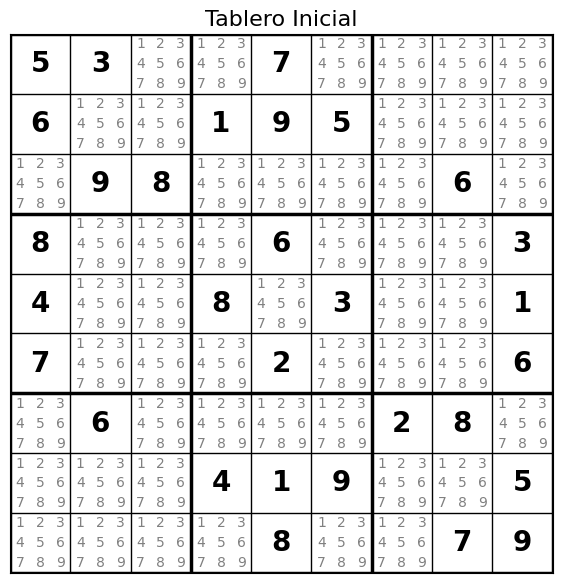

Resolviendo como Sudoku Estándar...


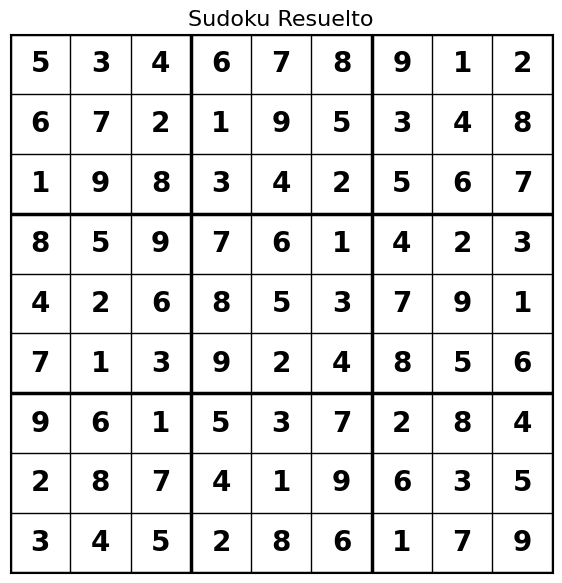

In [ ]:
# Crear el solver
solver = SudokuSolver(tablero_texto)

# Mostrar tablero inicial
solver.plot_display(title="Tablero Inicial", pause_time=0.5)

# Resolver Sudoku
resuelto = solver.resolver(tipo='estandar')

# Mostrar resultado final
if resuelto:
    solver.plot_display(resuelto, title="Sudoku Resuelto", pause_time=0.5)
else:
    print("No se pudo resolver el Sudoku.")